In [1]:
# Install the stumpy library
!pip install stumpy

import pandas as pd
import stumpy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as dates
from matplotlib.patches import Rectangle
import datetime as dt
import math

# 1. Load and Explore the Steamgen Dataset

In [2]:
# Load the steamgen dataset
steam_df = pd.read_csv('steamgen_anomalies.csv')

# Display the first few rows to understand its structure
print(steam_df.head())
print(steam_df.info())

   drum pressure  excess oxygen  water level  steam flow
0      320.08239       2.506774     0.032701    9.302970
1      321.71099       2.545908     0.284799    9.662621
2      320.91331       2.360562     0.203652   10.990955
3      325.00252       0.027054     0.326187   12.430107
4      326.65276       0.285649     0.753776   13.681666
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9600 entries, 0 to 9599
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   drum pressure  9600 non-null   float64
 1   excess oxygen  9600 non-null   float64
 2   water level    9600 non-null   float64
 3   steam flow     9600 non-null   float64
dtypes: float64(4)
memory usage: 300.1 KB
None


# 2. Visualizing the Steamgen Dataset

```
# 2. Visualizing the Steamgen Dataset
```



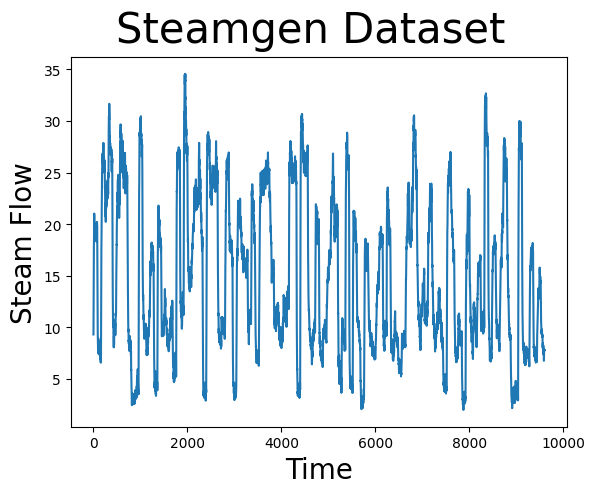

In [3]:
# Plot the 'steam flow' column
plt.suptitle('Steamgen Dataset', fontsize='30')
plt.xlabel('Time', fontsize='20')
plt.ylabel('Steam Flow', fontsize='20')
plt.plot(steam_df['steam flow'].values)
plt.show()

# 3. Identifying a Motif (Pattern) Using STUMPY


In [4]:
# Choose a window size. For this dataset, 640 is used as an example, roughly half-hour windows.
m = 640

# Compute the matrix profile using stumpy.stump
mp = stumpy.stump(steam_df['steam flow'], m)

# Display the resulting matrix profile array
print(mp)


[[16.235411477247823 2242 -1 2242]
 [16.08191866323061 2243 -1 2243]
 [15.909403017873426 2245 -1 2245]
 ...
 [9.02293137221496 877 877 -1]
 [9.038259675949295 878 878 -1]
 [9.054692514421284 879 879 -1]]


In [9]:
# Find the minimum value in the matrix profile (the distance of the top motif)
print( "Minimum matrix profile value:", mp[:, 0].min())

# Find the index of the motif (the subsequence with the smallest matrix profile value)
motif_idx = np.argmin(mp[:, 0])
print(f"The motif is located at index {motif_idx}")

# Find the index of the motif's nearest neighbor
nearest_neighbor_idx = mp[motif_idx, 1]
print(f"The nearest neighbor is located at index {nearest_neighbor_idx}")

# Print the distance between the two motifs
print(f"Distance between motif and its neighbor: {mp[motif_idx, 0]}")

Minimum matrix profile value: 5.491619827769537
The motif is located at index 643
The nearest neighbor is located at index 8724
Distance between motif and its neighbor: 5.491619827769537


# 4. Visualizing the Motif

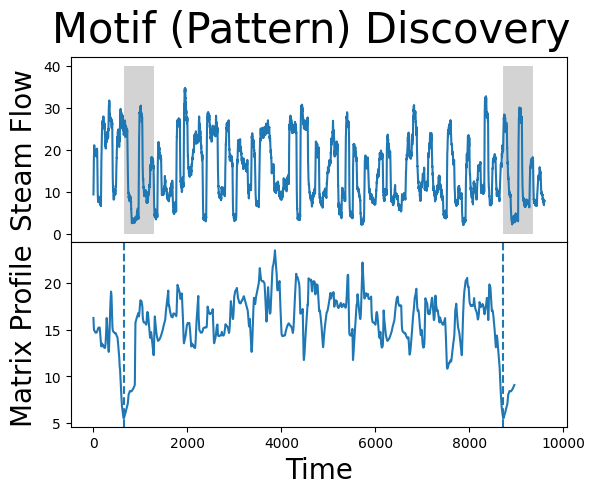

In [10]:
fig, axs = plt.subplots(2, sharex=True, gridspec_kw={'hspace': 0})
plt.suptitle('Motif (Pattern) Discovery', fontsize='30')

# Plot the raw steam flow data
axs[0].plot(steam_df['steam flow'].values)
axs[0].set_ylabel('Steam Flow', fontsize='20')

# Highlight the motif and its nearest neighbor on the raw data plot
rect = Rectangle((motif_idx, 0), m, 40, facecolor='lightgrey')
axs[0].add_patch(rect)
rect = Rectangle((nearest_neighbor_idx, 0), m, 40, facecolor='lightgrey')
axs[0].add_patch(rect)

# Plot the matrix profile
axs[1].set_xlabel('Time', fontsize='20')
axs[1].set_ylabel('Matrix Profile', fontsize='20')
axs[1].axvline(x=motif_idx, linestyle="dashed")
axs[1].axvline(x=nearest_neighbor_idx, linestyle="dashed")
axs[1].plot(mp[:, 0])

plt.show()

# 5. Identifying Potential Anomalies (Discords)

In [11]:
# Find the index of the discord (the subsequence with the largest matrix profile value)
discord_idx = np.argmax(mp[:, 0])
print(f"The discord is located at index {discord_idx}")

# Find the distance to its nearest neighbor
nearest_neighbor_distance = mp[discord_idx, 0]
print(f"The nearest neighbor subsequence to this discord is {nearest_neighbor_distance} units away")

The discord is located at index 3864
The nearest neighbor subsequence to this discord is 23.476168367302016 units away


# 6. Visualizing the Discord

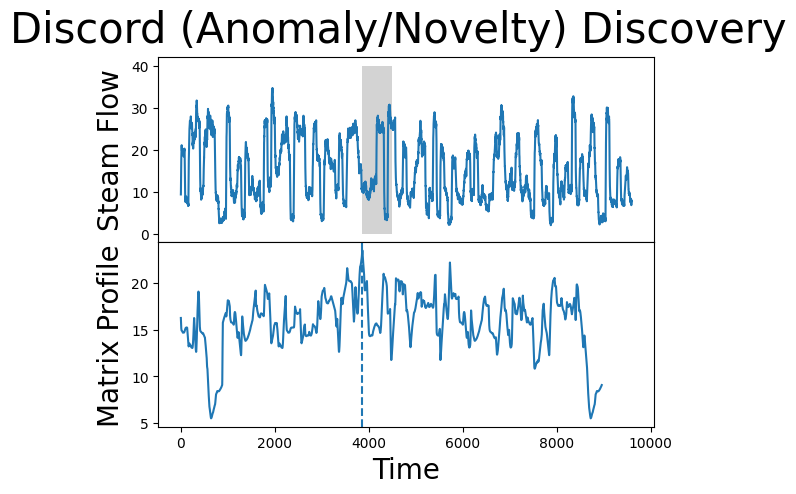

In [12]:
fig, axs = plt.subplots(2, sharex=True, gridspec_kw={'hspace': 0})
plt.suptitle('Discord (Anomaly/Novelty) Discovery', fontsize='30')

# Plot the raw steam flow data
axs[0].plot(steam_df['steam flow'].values)
axs[0].set_ylabel('Steam Flow', fontsize='20')

# Highlight the discord on the raw data plot
rect = Rectangle((discord_idx, 0), m, 40, facecolor='lightgrey')
axs[0].add_patch(rect)

# Plot the matrix profile
axs[1].set_xlabel('Time', fontsize='20')
axs[1].set_ylabel('Matrix Profile', fontsize='20')
axs[1].axvline(x=discord_idx, linestyle="dashed")
axs[1].plot(mp[:, 0])

plt.show()

# Custom Anomaly Detection on Steamgen Dataset using Matrix Profile
```
#  AI Assisted Codes
```

In [14]:
# 1. Install required libraries (run this once)
!pip install stumpy pandas matplotlib numpy

# 2. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import stumpy
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


In [15]:
# 3. Load and preprocess the data
print("="*60)
print("STEP 1: Loading Steamgen Dataset")
print("="*60)

df = pd.read_csv('steamgen_anomalies.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Time range: {len(df)} data points")


STEP 1: Loading Steamgen Dataset
Dataset shape: (9600, 4)
Columns: ['drum pressure', 'excess oxygen', 'water level', 'steam flow']
Time range: 9600 data points



Steam Flow Statistics:
  Mean: 14.85
  Std: 7.57
  Min: 1.99
  Max: 34.57


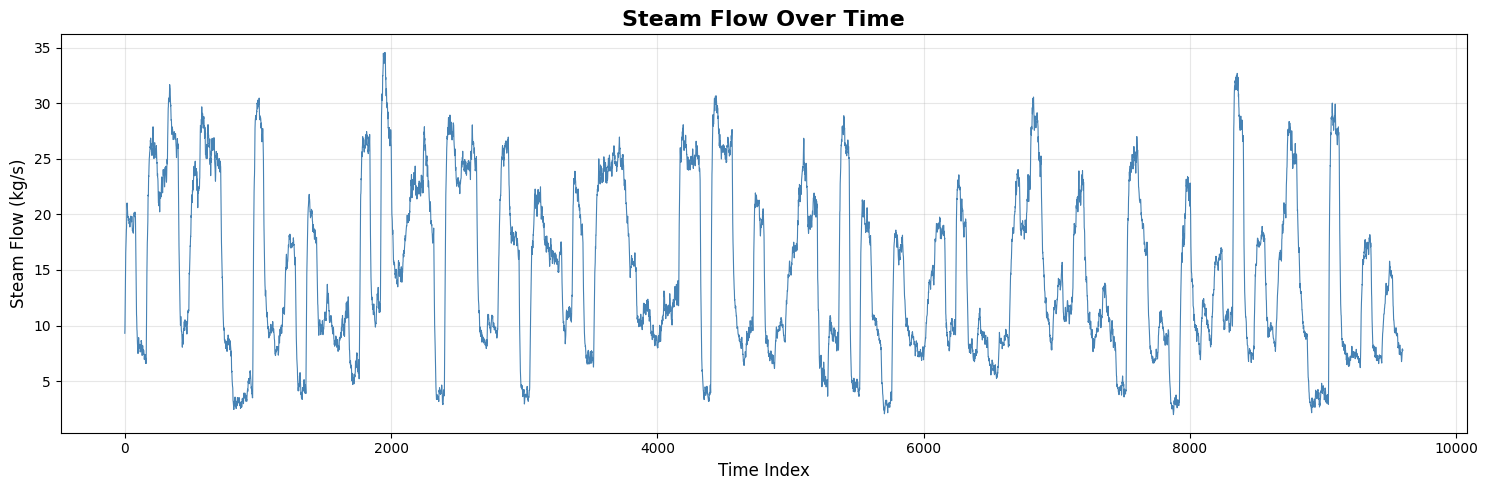

In [16]:
# Focus on the steam flow column
steam_flow = df['steam flow'].values
print(f"\nSteam Flow Statistics:")
print(f"  Mean: {steam_flow.mean():.2f}")
print(f"  Std: {steam_flow.std():.2f}")
print(f"  Min: {steam_flow.min():.2f}")
print(f"  Max: {steam_flow.max():.2f}")

# 4. Visualize the raw data
plt.figure(figsize=(15, 5))
plt.plot(steam_flow, color='steelblue', linewidth=0.8)
plt.title('Steam Flow Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Time Index', fontsize=12)
plt.ylabel('Steam Flow (kg/s)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


STEP 2: Computing Matrix Profile

Computing for window size m = 320...

Computing for window size m = 640...

Computing for window size m = 960...


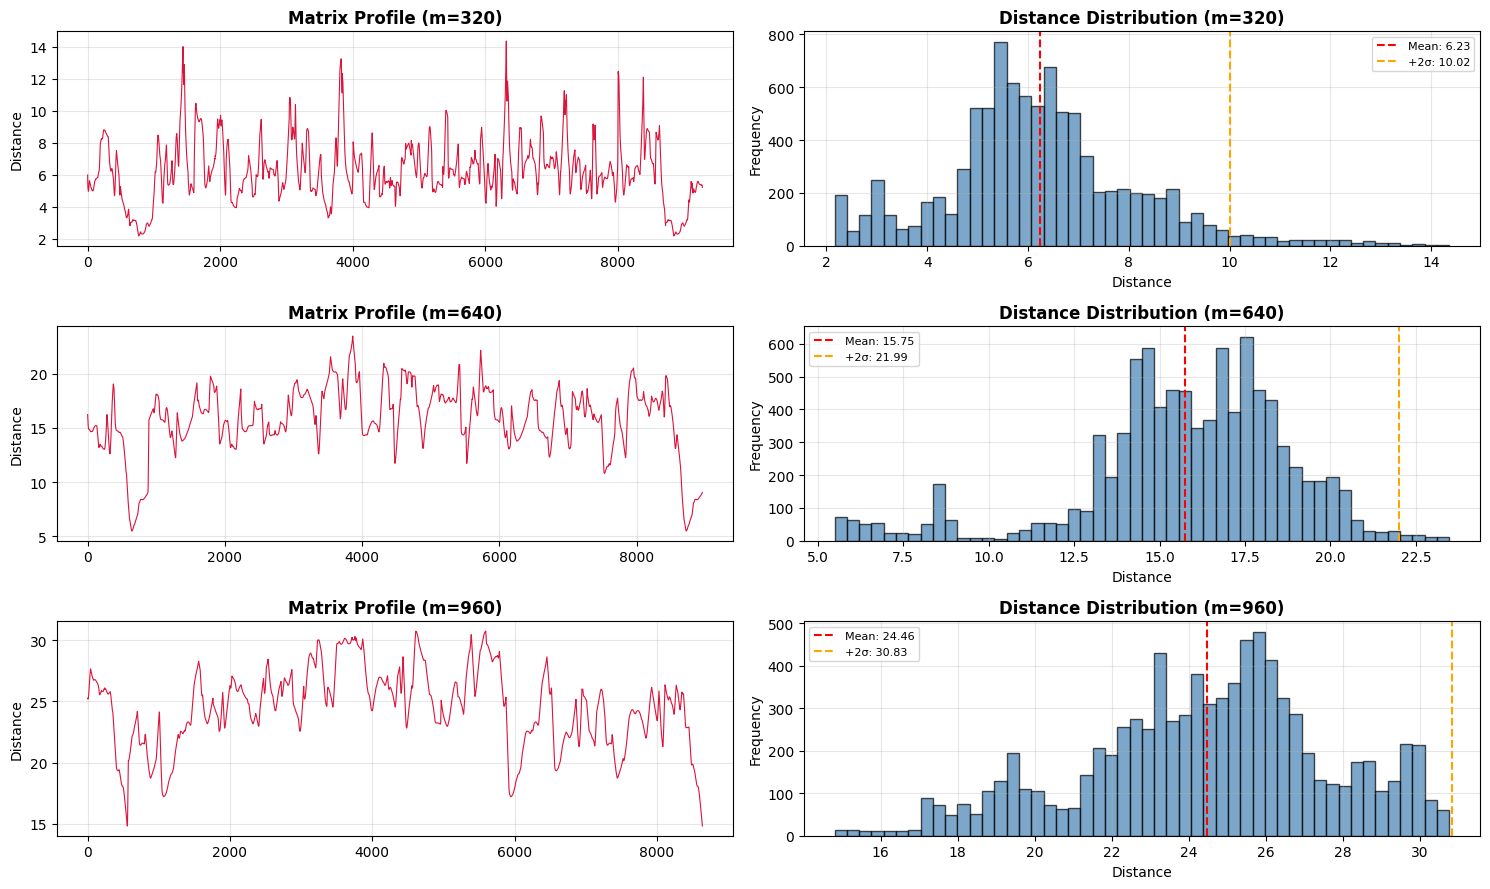

In [20]:
# 5. Choose window size (domain knowledge: ~30-second patterns)
print("\n" + "="*60)
print("STEP 2: Computing Matrix Profile")
print("="*60)

# Try different window sizes to see their effect
window_sizes = [320, 640, 960]  # Small, medium, large windows
matrix_profiles = {}

fig, axes = plt.subplots(len(window_sizes), 2, figsize=(15, 9))

for i, m in enumerate(window_sizes):
    print(f"\nComputing for window size m = {m}...")

    # Compute matrix profile
    mp = stumpy.stump(steam_flow, m)
    matrix_profiles[m] = mp

    # Explicitly convert the first column to a float array to ensure np.isfinite works
    # This handles cases where stumpy might return an object dtype mparray
    mp_distances_float = mp[:, 0].astype(np.float64)

    # Filter out non-finite values for plotting and statistics
    mp_finite = mp_distances_float[np.isfinite(mp_distances_float)]

    # Plot the matrix profile
    axes[i, 0].plot(mp_distances_float, color='crimson', linewidth=0.8)
    axes[i, 0].set_title(f'Matrix Profile (m={m})', fontweight='bold')
    axes[i, 0].set_ylabel('Distance')
    axes[i, 0].grid(True, alpha=0.3)

    # Plot histogram of distances
    axes[i, 1].hist(mp_finite, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i, 1].set_title(f'Distance Distribution (m={m})', fontweight='bold')
    axes[i, 1].set_xlabel('Distance')
    axes[i, 1].set_ylabel('Frequency')
    axes[i, 1].grid(True, alpha=0.3)

    # Add statistics, using nanmean and nanstd to handle potential NaNs safely
    mean_dist = np.nanmean(mp_finite)
    std_dist = np.nanstd(mp_finite)
    axes[i, 1].axvline(mean_dist, color='red', linestyle='--', label=f'Mean: {mean_dist:.2f}')
    axes[i, 1].axvline(mean_dist + 2*std_dist, color='orange', linestyle='--', label=f'+2σ: {mean_dist + 2*std_dist:.2f}')
    axes[i, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [22]:
# 6. Choose best window size (640 seems reasonable based on the original notebook)
print("\n" + "="*60)
print("STEP 3: Selecting Optimal Window Size")
print("="*60)

best_m = 640
mp_best = matrix_profiles[best_m]

# Convert the matrix profile distances to a float array for z-score calculation
mp_distances_float = mp_best[:, 0].astype(np.float64)

# Calculate anomaly scores (z-scores of matrix profile values)
anomaly_scores = stats.zscore(mp_distances_float)
anomaly_threshold = 2.5  # Threshold for considering a point as anomaly

# Find potential anomalies
anomaly_indices = np.where(anomaly_scores > anomaly_threshold)[0]
print(f"Selected window size: {best_m}")
print(f"Number of potential anomalies detected: {len(anomaly_indices)}")
print(f"Anomaly threshold: {anomaly_threshold:.2f} standard deviations")


STEP 3: Selecting Optimal Window Size
Selected window size: 640
Number of potential anomalies detected: 0
Anomaly threshold: 2.50 standard deviations


In [23]:
# 7. Identify top motif and top discord
print("\n" + "="*60)
print("STEP 4: Identifying Key Patterns")
print("="*60)

# Top motif (most repeated pattern)
top_motif_idx = np.argmin(mp_best[:, 0])
top_motif_neighbor = mp_best[top_motif_idx, 1]
top_motif_distance = mp_best[top_motif_idx, 0]

# Top discord (most unusual pattern)
top_discord_idx = np.argmax(mp_best[:, 0])
top_discord_distance = mp_best[top_discord_idx, 0]

print("TOP MOTIF (Most Repeated Pattern):")
print(f"  Location: Index {top_motif_idx}")
print(f"  Nearest Neighbor: Index {top_motif_neighbor}")
print(f"  Distance to neighbor: {top_motif_distance:.4f}")

print("\nTOP DISCORD (Most Unusual Pattern):")
print(f"  Location: Index {top_discord_idx}")
print(f"  Distance to nearest neighbor: {top_discord_distance:.4f}")



STEP 4: Identifying Key Patterns
TOP MOTIF (Most Repeated Pattern):
  Location: Index 643
  Nearest Neighbor: Index 8724
  Distance to neighbor: 5.4916

TOP DISCORD (Most Unusual Pattern):
  Location: Index 3864
  Distance to nearest neighbor: 23.4762



STEP 5: Creating Comprehensive Visualization


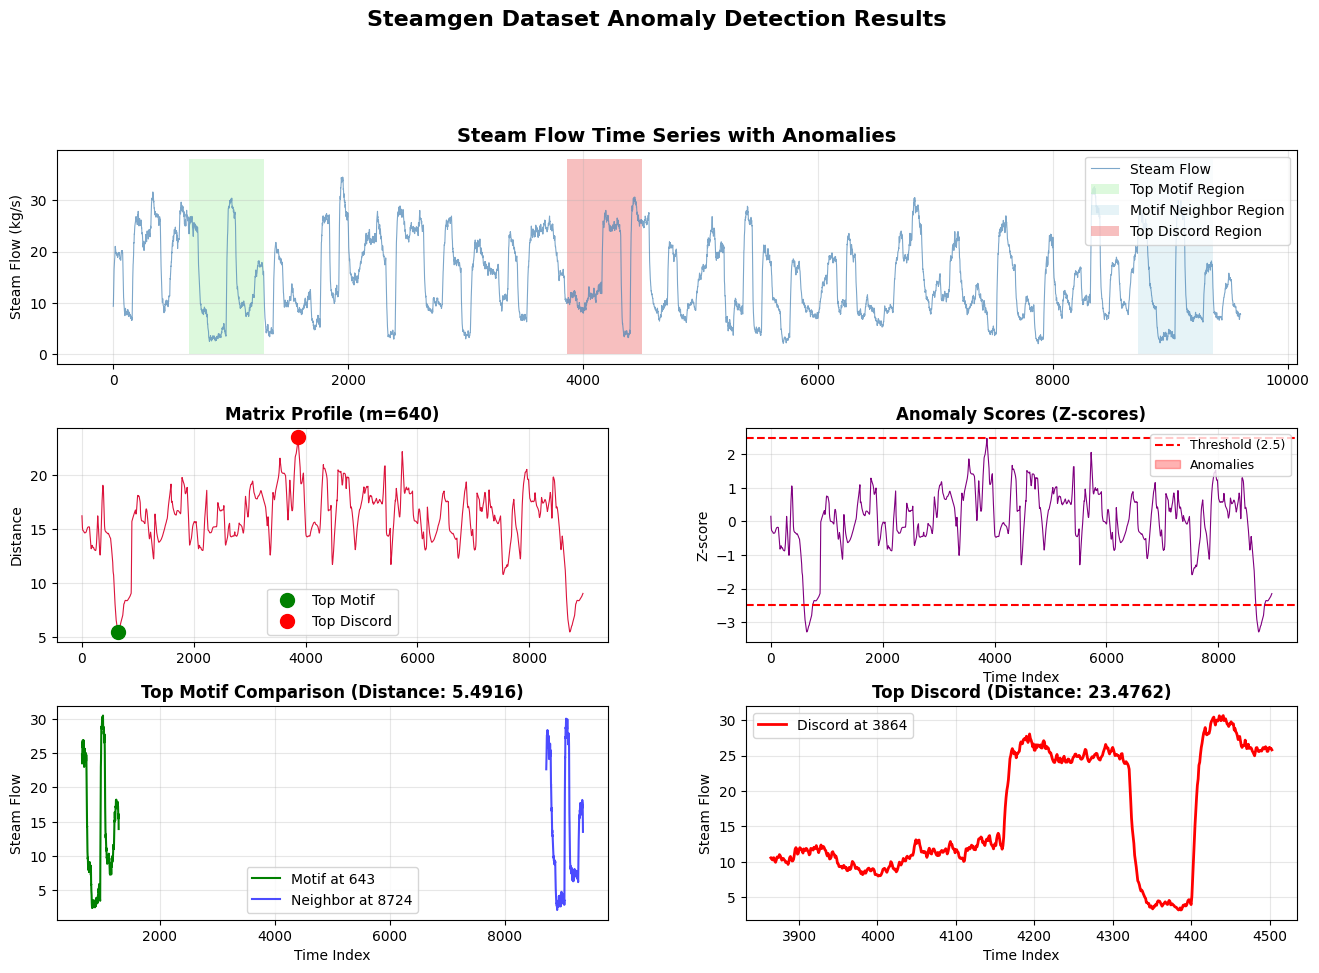

In [24]:
# 8. Create comprehensive visualization
print("\n" + "="*60)
print("STEP 5: Creating Comprehensive Visualization")
print("="*60)

fig = plt.figure(figsize=(16, 10))

# Create subplot grid
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.25)

# Main time series plot (top row, spans both columns)
ax0 = fig.add_subplot(gs[0, :])
ax0.plot(steam_flow, color='steelblue', linewidth=0.8, alpha=0.7, label='Steam Flow')
ax0.set_title('Steam Flow Time Series with Anomalies', fontsize=14, fontweight='bold')
ax0.set_ylabel('Steam Flow (kg/s)')
ax0.grid(True, alpha=0.3)

# Highlight motif region
motif_rect = Rectangle((top_motif_idx, 0), best_m, max(steam_flow)*1.1,
                       facecolor='lightgreen', alpha=0.3, label='Top Motif Region')
ax0.add_patch(motif_rect)

# Highlight neighbor region
neighbor_rect = Rectangle((top_motif_neighbor, 0), best_m, max(steam_flow)*1.1,
                          facecolor='lightblue', alpha=0.3, label='Motif Neighbor Region')
ax0.add_patch(neighbor_rect)

# Highlight discord region
discord_rect = Rectangle((top_discord_idx, 0), best_m, max(steam_flow)*1.1,
                         facecolor='lightcoral', alpha=0.5, label='Top Discord Region')
ax0.add_patch(discord_rect)

ax0.legend(loc='upper right', fontsize=10)

# Matrix profile plot (second row, left)
ax1 = fig.add_subplot(gs[1, 0])
ax1.plot(mp_best[:, 0], color='crimson', linewidth=0.8)
ax1.set_title('Matrix Profile (m=640)', fontweight='bold')
ax1.set_ylabel('Distance')
ax1.grid(True, alpha=0.3)

# Mark top motif and discord on matrix profile
ax1.plot(top_motif_idx, mp_best[top_motif_idx, 0], 'go', markersize=10, label='Top Motif')
ax1.plot(top_discord_idx, mp_best[top_discord_idx, 0], 'ro', markersize=10, label='Top Discord')
ax1.legend()

# Anomaly scores plot (second row, right)
ax2 = fig.add_subplot(gs[1, 1])
ax2.plot(anomaly_scores, color='purple', linewidth=0.8)
ax2.axhline(y=anomaly_threshold, color='red', linestyle='--', label=f'Threshold ({anomaly_threshold})')
ax2.axhline(y=-anomaly_threshold, color='red', linestyle='--')
ax2.fill_between(range(len(anomaly_scores)), anomaly_threshold, anomaly_scores,
                 where=(anomaly_scores > anomaly_threshold), color='red', alpha=0.3, label='Anomalies')
ax2.set_title('Anomaly Scores (Z-scores)', fontweight='bold')
ax2.set_ylabel('Z-score')
ax2.set_xlabel('Time Index')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', fontsize=9)

# Zoomed view of top motif (third row, left)
ax3 = fig.add_subplot(gs[2, 0])
motif_range = range(top_motif_idx, top_motif_idx + best_m)
neighbor_range = range(top_motif_neighbor, top_motif_neighbor + best_m)

ax3.plot(motif_range, steam_flow[top_motif_idx:top_motif_idx+best_m],
         'g-', linewidth=1.5, label=f'Motif at {top_motif_idx}')
ax3.plot(neighbor_range, steam_flow[top_motif_neighbor:top_motif_neighbor+best_m],
         'b-', linewidth=1.5, alpha=0.7, label=f'Neighbor at {top_motif_neighbor}')
ax3.set_title(f'Top Motif Comparison (Distance: {top_motif_distance:.4f})', fontweight='bold')
ax3.set_ylabel('Steam Flow')
ax3.set_xlabel('Time Index')
ax3.legend()
ax3.grid(True, alpha=0.3)


# Zoomed view of top discord (third row, right)
ax4 = fig.add_subplot(gs[2, 1])
discord_range = range(top_discord_idx, top_discord_idx + best_m)
ax4.plot(discord_range, steam_flow[top_discord_idx:top_discord_idx+best_m],
         'r-', linewidth=2, label=f'Discord at {top_discord_idx}')
ax4.set_title(f'Top Discord (Distance: {top_discord_distance:.4f})', fontweight='bold')
ax4.set_ylabel('Steam Flow')
ax4.set_xlabel('Time Index')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('Steamgen Dataset Anomaly Detection Results', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [26]:
# 9. Generate summary report
print("\n" + "="*60)
print("SUMMARY REPORT: Anomaly Detection Results")
print("="*60)

print(f"\nDataset Information:")
print(f"  Total data points: {len(steam_flow)}")
print(f"  Window size used: {best_m}")

print(f"\nMatrix Profile Statistics:")
# Use the already converted mp_distances_float for statistics
print(f"  Mean distance: {np.nanmean(mp_distances_float):.4f}")
print(f"  Std distance: {np.nanstd(mp_distances_float):.4f}")
print(f"  Min distance (top motif): {np.nanmin(mp_distances_float):.4f}")
print(f"  Max distance (top discord): {np.nanmax(mp_distances_float):.4f}")

print(f"\nTop 5 Anomalies (by anomaly score):")
top_anomalies = sorted(zip(anomaly_indices, anomaly_scores[anomaly_indices]),
                       key=lambda x: x[1], reverse=True)[:5]
for i, (idx, score) in enumerate(top_anomalies, 1):
    print(f"  {i}. Index {idx}: Z-score = {score:.2f}, Distance = {mp_distances_float[idx]:.4f}")

print(f"\nTop Motif Details:")
print(f"  Location: Index {top_motif_idx}")
print(f"  Nearest neighbor: Index {top_motif_neighbor}")
print(f"  Pattern length: {best_m} points")
print(f"  Distance to neighbor: {top_motif_distance:.4f}")

print(f"\nTop Discord Details:")
print(f"  Location: Index {top_discord_idx}")
print(f"  Pattern length: {best_m} points")
print(f"  Distance to nearest neighbor: {top_discord_distance:.4f}")

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)


SUMMARY REPORT: Anomaly Detection Results

Dataset Information:
  Total data points: 9600
  Window size used: 640

Matrix Profile Statistics:
  Mean distance: 15.7534
  Std distance: 3.1206
  Min distance (top motif): 5.4916
  Max distance (top discord): 23.4762

Top 5 Anomalies (by anomaly score):

Top Motif Details:
  Location: Index 643
  Nearest neighbor: Index 8724
  Pattern length: 640 points
  Distance to neighbor: 5.4916

Top Discord Details:
  Location: Index 3864
  Pattern length: 640 points
  Distance to nearest neighbor: 23.4762

ANALYSIS COMPLETE
